In [1]:
print("Importing Libraries")
import pandas as pd
print(".")
import numpy as np
print(".")
import gc
print(".")
import matplotlib.pyplot as plt
print(".")
import seaborn as sns
print(".")
from sklearn.feature_extraction.text import TfidfVectorizer
print(".")
from sklearn.preprocessing import LabelEncoder
print(".")
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(".")
import tensorflow as tf
print(".")
from tensorflow.keras.models import Sequential
print(".")
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
print("Libraries Imported")

Importing Libraries
.
.
.
.
.
.
.
.


2026-04-10 19:36:16.995723: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775849777.230624      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775849777.291826      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775849777.812935      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775849777.812982      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775849777.812985      23 computation_placer.cc:177] computation placer alr

.
.
Libraries Imported


In [2]:
def data_generator(X, y, batch_size=32):
    """
    Yields dense batches of data from a sparse matrix to save memory.
    """
    num_samples = X.shape[0]

    # Convert pandas Series to numpy arrays for easier slicing
    if isinstance(y, pd.Series):
        y = y.values

    while True:
        # Shuffle indices at the start of each epoch for better training
        indices = np.random.permutation(num_samples)

        for start in range(0, num_samples, batch_size):
            end = min(start + batch_size, num_samples)
            batch_idx = indices[start:end]

            # Slice the sparse matrix, then convert ONLY this tiny batch to dense
            X_batch = X[batch_idx].toarray()
            y_batch = y[batch_idx]

            yield X_batch, y_batch

class CustomMetricsPrinter(tf.keras.callbacks.Callback):
    def __init__(self, config):
        super().__init__()
        self.config = config

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        
        loss = logs.get('loss', 0.0)
        acc = logs.get('accuracy', 0.0)
        val_loss = logs.get('val_loss', 0.0)
        val_acc = logs.get('val_accuracy', 0.0)
        
        epochs = self.params['epochs']
        
        print(f"Epoch {epoch + 1}/{epochs}, Config: {self.config}")
        print(f"train_accuracy: {acc:.4f} - train_loss: {loss:.4f} - val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}")

In [3]:
print("Loading data...")
account = 'ayush3yadav'
dataset = 'original'
dataset = 'one-percent'
train_df = pd.read_parquet(f'/kaggle/input/datasets/{account}/{dataset}/train.parquet')
print(".")
val_df   = pd.read_parquet(f'/kaggle/input/datasets/{account}/{dataset}/val.parquet')
print(".")
test_df  = pd.read_parquet(f'/kaggle/input/datasets/{account}/{dataset}/test.parquet')
print("Data Loaded")
print(f'Data size: {dataset}')

Loading data...
.
.
Data Loaded
Data size: one-percent


In [4]:
num_classes = train_df['generated_by'].nunique()
num_classes

12

In [5]:
text_col = 'text'
label_col = 'generated_by'

In [6]:
X_train_raw, y_train = train_df[text_col], train_df[label_col]
X_val_raw,   y_val   = val_df[text_col],   val_df[label_col]
X_test_raw,  y_test  = test_df[text_col],  test_df[label_col]

In [7]:
print('Encoding labels to integers...')
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
print(".")

y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)
print(f"Detected {num_classes} unique classes: {label_encoder.classes_}")
print(".")
print('Labels Encoded Successfully')

Encoding labels to integers...
.
Detected 12 unique classes: ['chatgpt' 'cohere' 'cohere-chat' 'gpt2' 'gpt3' 'gpt4' 'human'
 'llama-chat' 'mistral' 'mistral-chat' 'mpt' 'mpt-chat']
.
Labels Encoded Successfully


In [8]:
print("Applying TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000, ngram_range = (1, 3))

X_train_tfidf = tfidf.fit_transform(X_train_raw)
print(".")
X_val_tfidf   = tfidf.transform(X_val_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)
print("TF-IDF Applied")

Applying TF-IDF...
.
TF-IDF Applied


In [9]:
X_train_final = X_train_tfidf
X_val_final   = X_val_tfidf
X_test_final  = X_test_tfidf

In [10]:
del train_df, val_df, test_df
del X_train_raw, X_val_raw, X_test_raw
del X_train_tfidf, X_val_tfidf, X_test_tfidf

gc.collect()

print("Old dataframes deleted and RAM cleared!")

Old dataframes deleted and RAM cleared!


In [11]:
print("Training and tuning Neural Networks...")

layer_configs = [(512, 256), (1024, 512), (2048, 1024), (4096, 2048), (8192, 4096)]

best_val_loss = float('inf')
best_val_acc = 0.0 
best_config = None
best_model = None

input_dim = X_train_final.shape[1]

for config in layer_configs:
    neurons_l1, neurons_l2 = config
    print(f"\nTraining config: Layer 1 = {neurons_l1} neurons, Layer 2 = {neurons_l2} neurons")

    model = Sequential([
        Input(shape=(input_dim,)),
        
        Dense(neurons_l1, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(neurons_l2, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    batch_size = 32

    steps_per_epoch = int(np.ceil(X_train_final.shape[0] / batch_size))
    val_steps = int(np.ceil(X_val_final.shape[0] / batch_size))

    model.fit(
        data_generator(X_train_final, y_train, batch_size),
        validation_data=data_generator(X_val_final, y_val, batch_size),
        steps_per_epoch=steps_per_epoch,
        validation_steps=val_steps,
        epochs=50, 
        verbose=0,
        callbacks=[CustomMetricsPrinter(config)]
    )

    val_loss, val_acc = model.evaluate(
        data_generator(X_val_final, y_val, batch_size),
        steps=val_steps,
        verbose=0 
    )
    print(f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_config = config
        best_model = model

print(f"\n==========================================")
print(f"BEST CONFIGURATION FOUND (Based on Lowest Val Loss):")
print(f"Layer 1: {best_config[0]} neurons | Layer 2: {best_config[1]} neurons")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Associated Validation Accuracy: {best_val_acc:.4f}")
print(f"==========================================\n")

Training and tuning Neural Networks...

Training config: Layer 1 = 512 neurons, Layer 2 = 256 neurons


I0000 00:00:1775849815.080485      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775849815.086143      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1775849818.091169      76 service.cc:152] XLA service 0x7922340081f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775849818.091221      76 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775849818.091227      76 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775849818.504863      76 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775849820.652438      76 device_compiler.h:188] Compiled clust

Epoch 1/50, Config: (512, 256)
train_accuracy: 0.2377 - train_loss: 2.4896 - val_accuracy: 0.1958 - val_loss: 2.2950
Epoch 2/50, Config: (512, 256)
train_accuracy: 0.5606 - train_loss: 1.3078 - val_accuracy: 0.3252 - val_loss: 1.9171
Epoch 3/50, Config: (512, 256)
train_accuracy: 0.7423 - train_loss: 0.8107 - val_accuracy: 0.3682 - val_loss: 1.9890
Epoch 4/50, Config: (512, 256)
train_accuracy: 0.8193 - train_loss: 0.5622 - val_accuracy: 0.3643 - val_loss: 2.2155
Epoch 5/50, Config: (512, 256)
train_accuracy: 0.8559 - train_loss: 0.4493 - val_accuracy: 0.3750 - val_loss: 2.3477
Epoch 6/50, Config: (512, 256)
train_accuracy: 0.8817 - train_loss: 0.3817 - val_accuracy: 0.3672 - val_loss: 2.4884
Epoch 7/50, Config: (512, 256)
train_accuracy: 0.8815 - train_loss: 0.3666 - val_accuracy: 0.3770 - val_loss: 2.6583
Epoch 8/50, Config: (512, 256)
train_accuracy: 0.8834 - train_loss: 0.3518 - val_accuracy: 0.3799 - val_loss: 2.8391
Epoch 9/50, Config: (512, 256)
train_accuracy: 0.8889 - train_lo

Evaluating the best model on unseen Test Data...
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 201ms/step
Final Test Accuracy: 0.3645

Classification Report:
              precision    recall  f1-score   support

     chatgpt       0.49      0.49      0.49        83
      cohere       0.32      0.32      0.32        84
 cohere-chat       0.31      0.20      0.25        83
        gpt2       0.43      0.28      0.34        83
        gpt3       0.45      0.28      0.35        82
        gpt4       0.58      0.54      0.56        83
       human       0.20      0.46      0.28        83
  llama-chat       0.45      0.45      0.45        84
     mistral       0.24      0.27      0.25        82
mistral-chat       0.33      0.27      0.29        83
         mpt       0.47      0.46      0.46        83
    mpt-chat       0.38      0.35      0.36        83

    accuracy                           0.36       996
   macro avg       0.39      0.36      0.37       996
weighted avg       0.39      0.36      0.37   

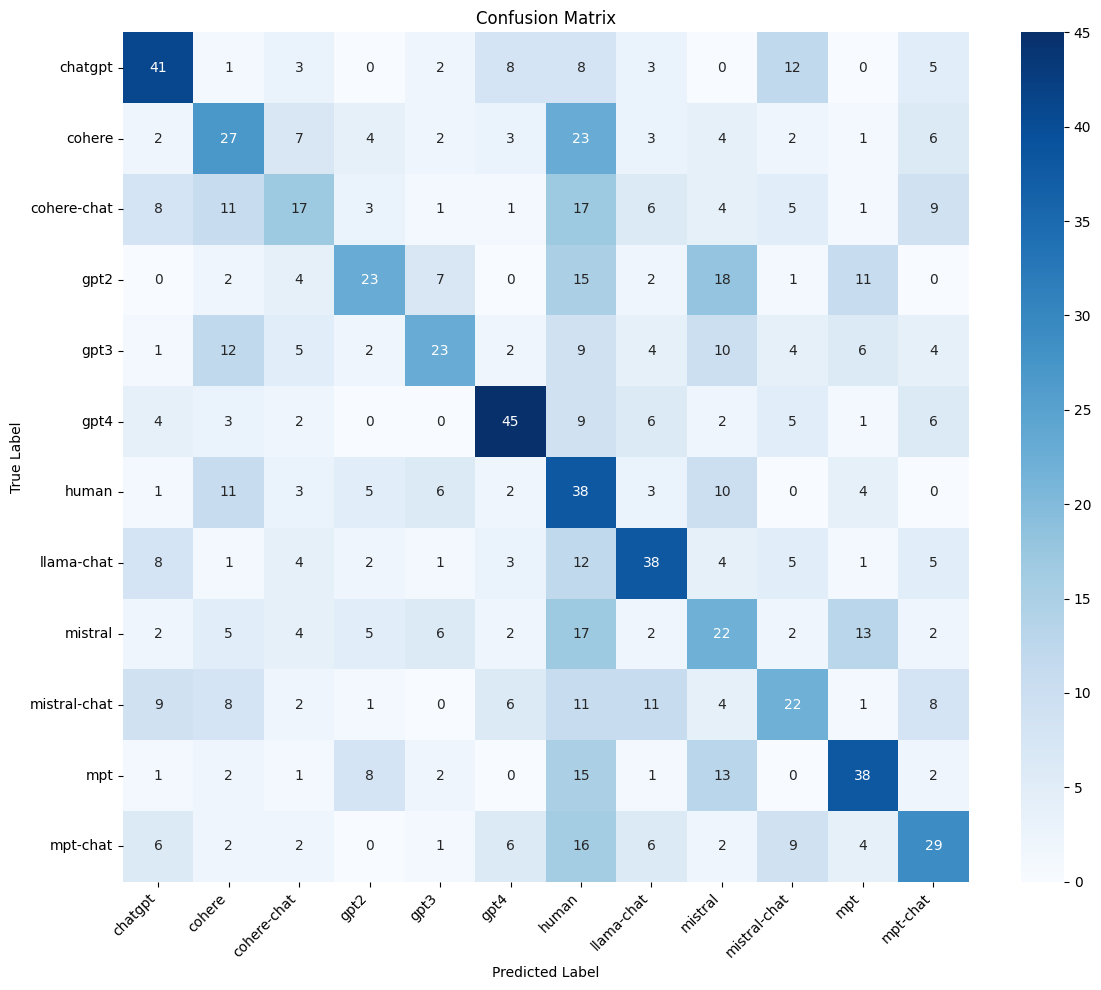

In [12]:
print("Evaluating the best model on unseen Test Data...")

# Get probability predictions
y_pred_probs = best_model.predict(X_test_final)

# Convert probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# Print final metrics
test_acc = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {test_acc:.4f}\n")
print("Classification Report:")
# You can also use target_names here to decode the classification report!
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# --- Plotting the Confusion Matrix Heatmap with Decoded Labels ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10)) # Made slightly larger to fit text
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)

plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Rotate x-axis labels so they are easier to read
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()